In [55]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [56]:
file = "genres_original/blues/blues.00000.wav"

In [3]:
# load audio file with Librosa
signal, sr = librosa.load(file)

Text(0.5, 1.0, 'Waveform')

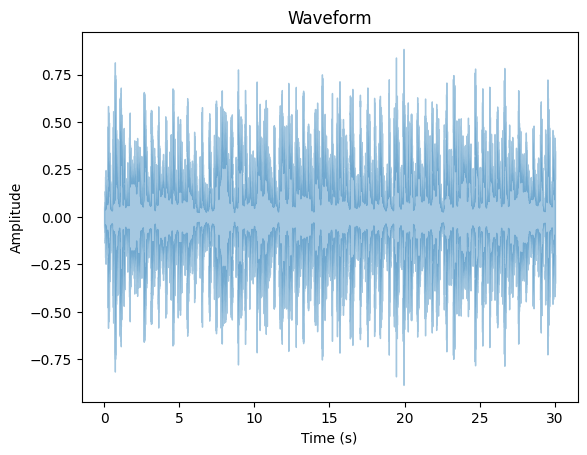

In [4]:
# WAVEFORM
# display waveform
librosa.display.waveshow(signal, alpha=0.4)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform")

In [5]:
# FFT -> power spectrum
# perform Fourier transform
fft = np.fft.fft(signal)

# calculate abs values on complex numbers to get magnitude
spectrum = np.abs(fft)

# create frequency variable
f = np.linspace(0, sr, len(spectrum))

# take half of the spectrum and frequency
left_spectrum = spectrum[: int(len(spectrum) / 2)]
left_f = f[: int(len(spectrum) / 2)]

Text(0.5, 1.0, 'Power spectrum')

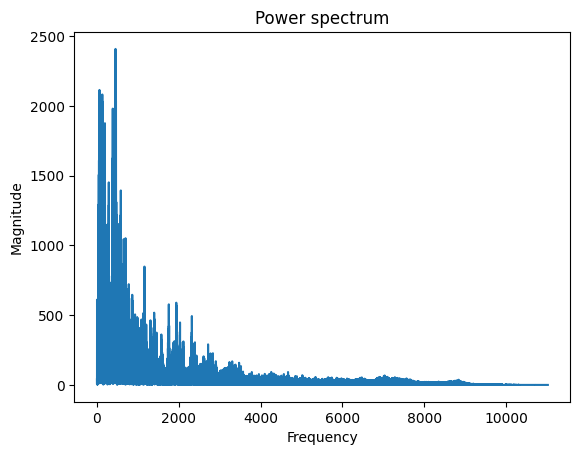

In [6]:
# plot spectrum
plt.plot(left_f, left_spectrum)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Power spectrum")

In [7]:
# STFT -> spectrogram
# perform stft
stft = librosa.stft(y=signal)

# calculate abs values on complex numbers to get magnitude
spectrogram = np.abs(stft)

Text(0.5, 1.0, 'Spectrogram')

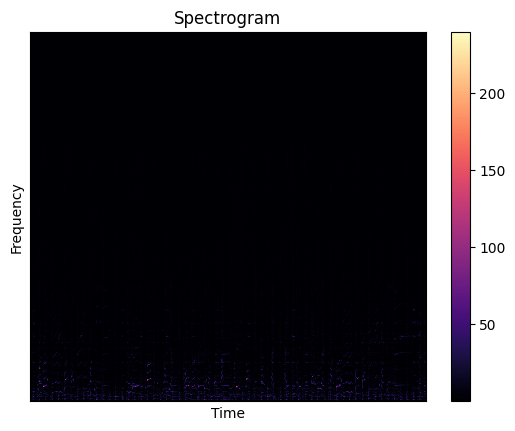

In [8]:
# display spectrogram
librosa.display.specshow(spectrogram)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.title("Spectrogram")

In [9]:
# apply logarithm to cast amplitude to Decibels
log_spectrogram = librosa.amplitude_to_db(spectrogram)

Text(0.5, 1.0, 'Spectrogram (dB)')

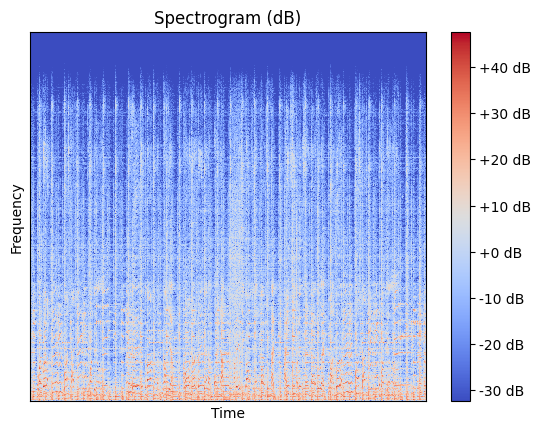

In [10]:
librosa.display.specshow(log_spectrogram)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (dB)")

In [11]:
# MFCCs
# extract 13 MFCCs
MFCCs = librosa.feature.mfcc(y=signal)

Text(0.5, 1.0, 'MFCCs')

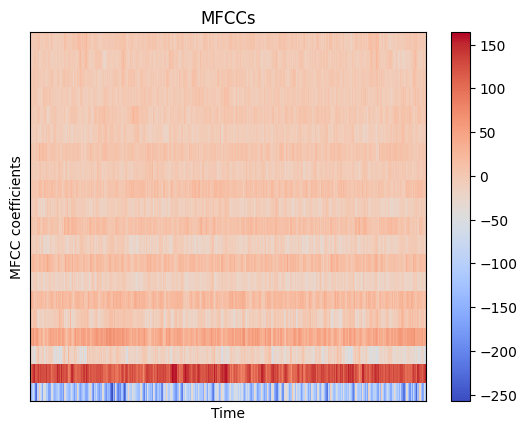

In [12]:
# display MFCCs
librosa.display.specshow(MFCCs)
plt.xlabel("Time")
plt.ylabel("MFCC coefficients")
plt.colorbar()
plt.title("MFCCs")

---
## 2. MFCC Feature Extraction

In [13]:
import os
import librosa
import math
import json
from pathlib import Path  # For cleaner path handling


def save_mfcc(
    dataset_path: str,
    json_path: str,
    n_mfcc=13,
    n_fft=2048,
    hop_length=512,
    num_segments=5,
):
    data = {
        "mapping": [],
        "mfcc": [],
        "labels": [],
    }

    num_samples_per_segment = int((22050 * 30) / num_segments)
    expected_vector_length = math.ceil(num_samples_per_segment / hop_length)

    for i, (dir_path, dir_names, filenames) in enumerate(os.walk(dataset_path)):
        if dir_path is not dataset_path:
            semantic_label = Path(dir_path).name  # Extract label from path
            data["mapping"].append(semantic_label)

            for f in filenames:
                file_path = os.path.join(dir_path, f)

                # Check file extension before loading
                if not file_path.endswith(
                    (".wav", ".flac", ".ogg")
                ):  # Add supported extensions
                    print(f"Skipping unsupported format: {file_path}")
                    continue

                try:
                    signal, sr = librosa.load(file_path)

                    for s in range(num_segments):
                        start_sample = num_samples_per_segment * s
                        finish_sample = start_sample + num_samples_per_segment

                        mfcc = librosa.feature.mfcc(
                            y=signal[start_sample:finish_sample],
                            sr=sr,
                            n_fft=n_fft,
                            n_mfcc=n_mfcc,
                            hop_length=hop_length,
                        )

                        mfcc = mfcc.T

                        if len(mfcc) == expected_vector_length:
                            data["mfcc"].append(mfcc.tolist())
                            data["labels"].append(i - 1)
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    with open(json_path, "w") as fp:
        json.dump(data, fp, indent=4)


save_mfcc(
    "genres_original",
    "processed.json",
    num_segments=10,
)

C:\Users\pc\AppData\Local\Temp\ipykernel_26004\3566942749.py:41: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path)
C:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error processing genres_original\jazz\jazz.00054.wav: 


---
## 3. Dense Neural Network Classifier

In [14]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from collections import Counter
import librosa
import math

In [15]:
def load_data(dataset_path):
    #open file
    with open(dataset_path, "r") as fp:
        data = json.load(fp)
    
    #convert lists in to numpy arrays
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])
    
    return inputs, targets

In [16]:
def plot_history(history):
    figure, axs = plt.subplots(2)

    # accuracy subplot
    axs[0].plot(history.history["accuracy"], label="Train Accuracy")
    axs[0].plot(history.history["val_accuracy"], label="Test Accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy Eval")

    # error subplot
    axs[1].plot(history.history["loss"], label="Train Error")
    axs[1].plot(history.history["val_loss"], label="Test Error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Error Eval")
    
    plt.show()

In [17]:
inputs, targets = load_data("processed.json") # load all the data

In [18]:
print(inputs.shape)
print(targets.shape)

(9986, 130, 13)
(9986,)


In [19]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.3)

In [20]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6990, 130, 13) (6990,)
(2996, 130, 13) (2996,)


In [21]:
# build the model architecture
dense_model = keras.Sequential([
    #input layer
    keras.layers.Flatten(input_shape=(inputs.shape[1], inputs.shape[2])),
    
    #hidden layers
    keras.layers.Dense(units=512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    
    #output layer
    keras.layers.Dense(units=10, activation='linear')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0001)
dense_model.compile(optimizer=optimizer, loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
dense_model.summary()

C:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 1690)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         865,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,014,218 (3.87 MB)

 Trainable params: 1,014,218 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# train the model on training set
dense_history = dense_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1489 - loss: 18.3472 - val_accuracy: 0.1041 - val_loss: 3.5178
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1266 - loss: 5.3005 - val_accuracy: 0.0995 - val_loss: 3.5110
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1193 - loss: 4.1020 - val_accuracy: 0.0981 - val_loss: 3.5092
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1232 - loss: 3.7907 - val_accuracy: 0.1008 - val_loss: 3.5056
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1189 - loss: 3.7008 - val_accuracy: 0.1055 - val_loss: 3.4975
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1219 - loss: 3.5884 - val_accuracy: 0.1145 - val_loss: 3.4700
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1227 - loss: 3.5854 - val_accuracy: 0.1148 - val_loss: 3.4646
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1243 - loss: 3.5603 - val_acc

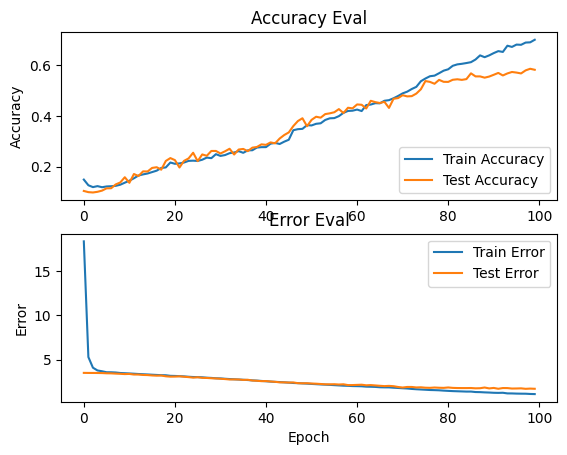

In [23]:
plot_history(dense_history)

In [24]:
dense_test_error, dense_test_accuracy = dense_model.evaluate(X_test, y_test, verbose=1)
print(f"Accuracy: {dense_test_accuracy}, Error: {dense_test_error}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5814 - loss: 1.7247
Accuracy: 0.5814419388771057, Error: 1.7246520519256592


In [25]:
import os
os.makedirs("weights", exist_ok=True)
dense_model.save("weights/weights.keras")

In [26]:
mapping = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock",
]

In [27]:
# Function to extract MFCCs from audio file
def extract_mfccs_from_audio(
    file_path,
    segment_duration=3,
    n_mfcc=13,
    n_fft=2048,
    hop_length=512,
    sample_rate=22050,
):
    signal, sr = librosa.load(file_path, sr=sample_rate)

    # Calculate the number of samples per segment
    samples_per_segment = sample_rate * segment_duration
    expected_vector_length = math.ceil(samples_per_segment / hop_length)

    mfccs = []
    num_segments = int(len(signal) / samples_per_segment)

    for s in range(num_segments):
        start_sample = samples_per_segment * s
        finish_sample = start_sample + samples_per_segment

        if finish_sample > len(signal):
            break

        mfcc = librosa.feature.mfcc(
            y=signal[start_sample:finish_sample],
            sr=sr,
            n_fft=n_fft,
            n_mfcc=n_mfcc,
            hop_length=hop_length,
        )
        mfcc = mfcc.T

        if len(mfcc) == expected_vector_length:
            mfccs.append(mfcc.tolist())

    return np.array(mfccs)

In [28]:
# Load the weights
dense_model.load_weights("weights/weights.keras")

In [29]:
mfccs = extract_mfccs_from_audio("genres_original/blues/blues.00000.wav")
predictions = dense_model.predict(mfccs)

probabilities = tf.nn.softmax(predictions, axis=-1)

predicted_classes = np.argmax(probabilities, axis=1)

class_counts = Counter(predicted_classes)
most_common_class = mapping[class_counts.most_common(1)[0][0]]

print(f"The predicted class for the song is: {most_common_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The predicted class for the song is: country


---
## 4. CNN Classifier

In [30]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import math
import librosa
import tensorflow as tf
from collections import Counter

In [31]:
def load_data(dataset_path):
    # open file
    with open(dataset_path, "r") as fp:
        data = json.load(fp)

    # convert lists in to numpy arrays
    X = np.array(data["mfcc"])
    y = np.array(data["labels"])

    return X, y

In [32]:
def prepare_datasets(test_size, valid_size):
    X, y = load_data("processed.json")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

    X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=valid_size)

    X_train = X_train[..., np.newaxis]
    X_valid = X_valid[..., np.newaxis]
    X_test = X_test[..., np.newaxis]
    
    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [33]:
X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_datasets(0.25, 0.2)

In [34]:
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])
cnn_model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPool2D((3,3), strides=(2,2), padding="same"),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPool2D((3,3), strides=(2,2), padding="same"),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(32, (2, 2), activation="relu"),
        keras.layers.MaxPool2D((2,2), strides=(2,2), padding="same"),
        keras.layers.BatchNormalization(),
        
        keras.layers.Flatten(),
        
        keras.layers.Dense(units=64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(units=10, activation="linear")
    ]
)
optimizer = keras.optimizers.Adam(0.0001)
cnn_model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [35]:
cnn_history = cnn_model.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size=32, epochs=30)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2120 - loss: 2.4680 - val_accuracy: 0.3351 - val_loss: 1.8784
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3746 - loss: 1.8432 - val_accuracy: 0.4186 - val_loss: 1.6101
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4243 - loss: 1.6666 - val_accuracy: 0.4653 - val_loss: 1.4626
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4547 - loss: 1.5347 - val_accuracy: 0.5093 - val_loss: 1.3674
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4832 - loss: 1.4478 - val_accuracy: 0.5354 - val_loss: 1.3094
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5193 - loss: 1.3618 - val_accuracy: 0.5614 - val_loss: 1.2526
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5448 - loss: 1.2840 - val_accuracy: 0.5794 - val_loss: 1.1874
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5567 - loss: 1.2385 - val_accuracy: 0.

In [36]:
cnn_test_error, cnn_test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)
print(f"Accuracy: {cnn_test_accuracy}, Error: {cnn_test_error}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6968 - loss: 0.8586
Accuracy: 0.6968362331390381, Error: 0.858620285987854


In [37]:
cnn_model.save("weights/cnn_weights.keras")

In [38]:
# Function to extract MFCCs from audio file
def extract_mfccs_from_audio(
    file_path,
    segment_duration=3,
    n_mfcc=13,
    n_fft=2048,
    hop_length=512,
    sample_rate=22050,
):
    signal, sr = librosa.load(file_path, sr=sample_rate)

    # Calculate the number of samples per segment
    samples_per_segment = sample_rate * segment_duration
    expected_vector_length = math.ceil(samples_per_segment / hop_length)

    mfccs = []
    num_segments = int(len(signal) / samples_per_segment)

    for s in range(num_segments):
        start_sample = samples_per_segment * s
        finish_sample = start_sample + samples_per_segment

        if finish_sample > len(signal):
            break

        mfcc = librosa.feature.mfcc(
            y=signal[start_sample:finish_sample],
            sr=sr,
            n_fft=n_fft,
            n_mfcc=n_mfcc,
            hop_length=hop_length,
        )
        mfcc = mfcc.T

        if len(mfcc) == expected_vector_length:
            mfccs.append(mfcc.tolist())

    return np.array(mfccs)

In [39]:
# Load the weights
cnn_model.load_weights("weights/cnn_weights.keras")

In [40]:
mapping = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock",
]

In [41]:
mfccs = extract_mfccs_from_audio("genres_original/metal/metal.00000.wav")
predictions = cnn_model.predict(mfccs)

probabilities = tf.nn.softmax(predictions, axis=-1)

predicted_classes = np.argmax(probabilities, axis=1)

class_counts = Counter(predicted_classes)
most_common_class = mapping[class_counts.most_common(1)[0][0]]

print(f"The predicted class for the song is: {most_common_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
The predicted class for the song is: metal


---
## 5. LSTM Classifier

In [42]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import math
import librosa
import tensorflow as tf
from collections import Counter

In [43]:
def load_data(dataset_path):
    # open file
    with open(dataset_path, "r") as fp:
        data = json.load(fp)

    # convert lists in to numpy arrays
    X = np.array(data["mfcc"])
    y = np.array(data["labels"])

    return X, y

In [44]:
def prepare_datasets(test_size, valid_size):
    X, y = load_data("processed.json")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=valid_size)
    
    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [45]:
X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_datasets(0.25, 0.2)

In [46]:
input_shape = (X_train.shape[1], X_train.shape[2])
lstm_model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        
        keras.layers.LSTM(units=64, return_sequences=True),
        keras.layers.LSTM(units=64),
        keras.layers.Dense(units=64, activation="relu"),
        keras.layers.Dropout(0.3),
        
        keras.layers.Dense(units=10, activation="linear")
    ]
)
optimizer = keras.optimizers.Adam(0.0001)
lstm_model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [47]:
lstm_history = lstm_model.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size=32, epochs=30)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.1751 - loss: 2.2036 - val_accuracy: 0.2623 - val_loss: 2.0843
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2984 - loss: 1.9907 - val_accuracy: 0.3458 - val_loss: 1.8617
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.3639 - loss: 1.7988 - val_accuracy: 0.4092 - val_loss: 1.6877
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.4206 - loss: 1.6533 - val_accuracy: 0.4660 - val_loss: 1.5565
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4637 - loss: 1.5363 - val_accuracy: 0.5033 - val_loss: 1.4642
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.4914 - loss: 1.4532 - val_accuracy: 0.5207 - val_loss: 1.4056
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5098 - loss: 1.3929 - val_accuracy: 0.5220 - val_loss: 1.3824
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5361 - loss: 1.3302 - val_accu

In [48]:
lstm_test_error, lstm_test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=1)
print(f"Accuracy: {lstm_test_accuracy}, Error: {lstm_test_error}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6376 - loss: 1.0899
Accuracy: 0.6375650763511658, Error: 1.089909315109253


In [49]:
lstm_model.save("weights/lstm_weights.keras")

In [50]:
# Function to extract MFCCs from audio file
def extract_mfccs_from_audio(
    file_path,
    segment_duration=3,
    n_mfcc=13,
    n_fft=2048,
    hop_length=512,
    sample_rate=22050,
):
    signal, sr = librosa.load(file_path, sr=sample_rate)

    # Calculate the number of samples per segment
    samples_per_segment = sample_rate * segment_duration
    expected_vector_length = math.ceil(samples_per_segment / hop_length)

    mfccs = []
    num_segments = int(len(signal) / samples_per_segment)

    for s in range(num_segments):
        start_sample = samples_per_segment * s
        finish_sample = start_sample + samples_per_segment

        if finish_sample > len(signal):
            break

        mfcc = librosa.feature.mfcc(
            y=signal[start_sample:finish_sample],
            sr=sr,
            n_fft=n_fft,
            n_mfcc=n_mfcc,
            hop_length=hop_length,
        )
        mfcc = mfcc.T

        if len(mfcc) == expected_vector_length:
            mfccs.append(mfcc.tolist())

    return np.array(mfccs)

In [51]:
# Load the weights
lstm_model.load_weights("weights/lstm_weights.keras")

In [52]:
mapping = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock",
]

In [53]:
mfccs = extract_mfccs_from_audio("genres_original/metal/metal.00000.wav")
predictions = lstm_model.predict(mfccs)

probabilities = tf.nn.softmax(predictions, axis=-1)

predicted_classes = np.argmax(probabilities, axis=1)

class_counts = Counter(predicted_classes)
most_common_class = mapping[class_counts.most_common(1)[0][0]]

print(f"The predicted class for the song is: {most_common_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
The predicted class for the song is: metal


---
## 6. Model Comparison

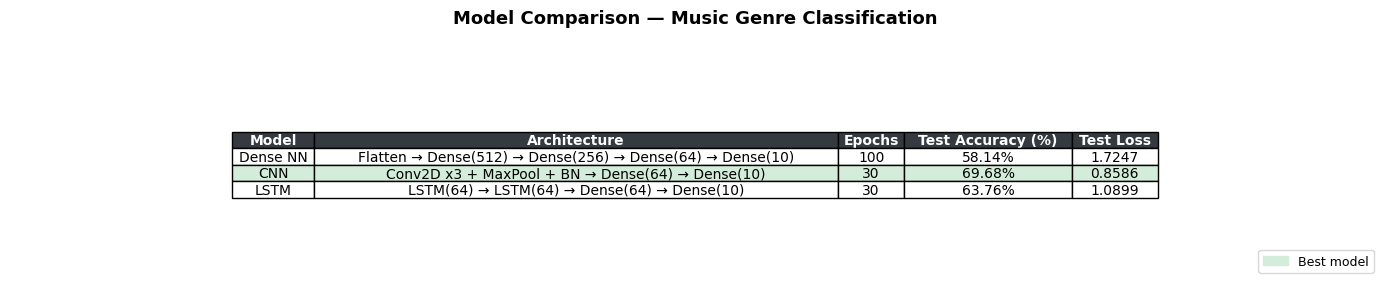

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model_names = ["Dense NN", "CNN", "LSTM"]
accuracies = [
    round(dense_test_accuracy * 100, 2),
    round(cnn_test_accuracy * 100, 2),
    round(lstm_test_accuracy * 100, 2),
]
errors = [
    round(dense_test_error, 4),
    round(cnn_test_error, 4),
    round(lstm_test_error, 4),
]
epochs = [100, 30, 30]
architectures = [
    "Flatten → Dense(512) → Dense(256) → Dense(64) → Dense(10)",
    "Conv2D x3 + MaxPool + BN → Dense(64) → Dense(10)",
    "LSTM(64) → LSTM(64) → Dense(64) → Dense(10)",
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

col_labels = ["Model", "Architecture", "Epochs", "Test Accuracy (%)", "Test Loss"]
table_data = [
    [model_names[i], architectures[i], epochs[i], f"{accuracies[i]:.2f}%", f"{errors[i]:.4f}"]
    for i in range(3)
]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(col_labels))))

best_idx = accuracies.index(max(accuracies))
for col in range(len(col_labels)):
    table[best_idx + 1, col].set_facecolor("#d4edda")

for col in range(len(col_labels)):
    table[0, col].set_facecolor("#343a40")
    table[0, col].set_text_props(color="white", fontweight="bold")

plt.title("Model Comparison — Music Genre Classification", fontsize=13, fontweight="bold", pad=20)
green_patch = mpatches.Patch(color="#d4edda", label="Best model")
plt.legend(handles=[green_patch], loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()